<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Practica_3_Clasificacion_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#NumPy permitirá realizar operaciones numéricas y
#Matplotlib permitirá graficar los resultados del entrenamiento.

import numpy as np
import matplotlib.pyplot as plt

En esta práctica se utilizará el problema lógico XOR, el cual es un caso clásico dentro del
estudio de redes neuronales. A diferencia de la compuerta AND, el problema XOR no
puede resolverse correctamente con un perceptrón simple, debido a que sus datos no son
linealmente separables. Por esta razón, se requiere una red neuronal con al menos una
capa oculta.

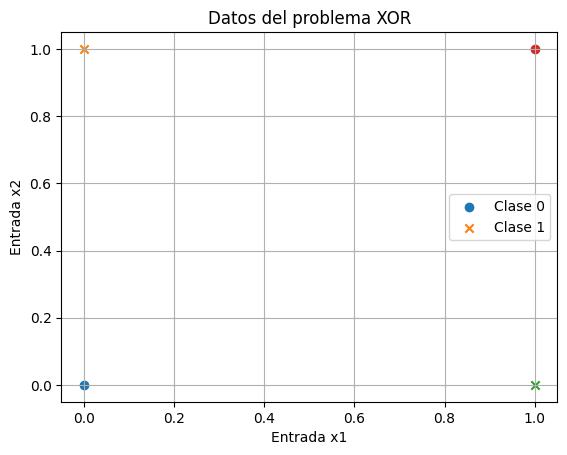

Época: 0 Error: 0.332182504663897
Época: 1000 Error: 0.05650081437632827
Época: 2000 Error: 0.0036905855238228017
Época: 3000 Error: 0.0015688080642976409
Época: 4000 Error: 0.000961512926039055
Época: 5000 Error: 0.000684013517445775
Época: 6000 Error: 0.0005272692107887482
Época: 7000 Error: 0.00042727915812859206
Época: 8000 Error: 0.000358247946568493
Época: 9000 Error: 0.0003078710182724831
Predicciones finales:
[[0.0142218 ]
 [0.99055716]
 [0.97896526]
 [0.0185573 ]]
Clases predichas:
[[0]
 [1]
 [1]
 [0]]
Comparación de resultados:
Entrada: [0 0]
Salida esperada: 0
Predicción: 0.014221796751927921
Clase predicha: 0
-----------------------------
Entrada: [0 1]
Salida esperada: 1
Predicción: 0.9905571624183505
Clase predicha: 1
-----------------------------
Entrada: [1 0]
Salida esperada: 1
Predicción: 0.9789652648566044
Clase predicha: 1
-----------------------------
Entrada: [1 1]
Salida esperada: 0
Predicción: 0.018557304313178168
Clase predicha: 0
-----------------------------


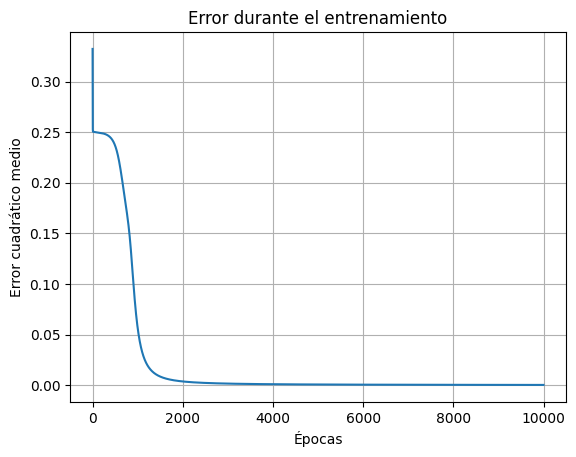

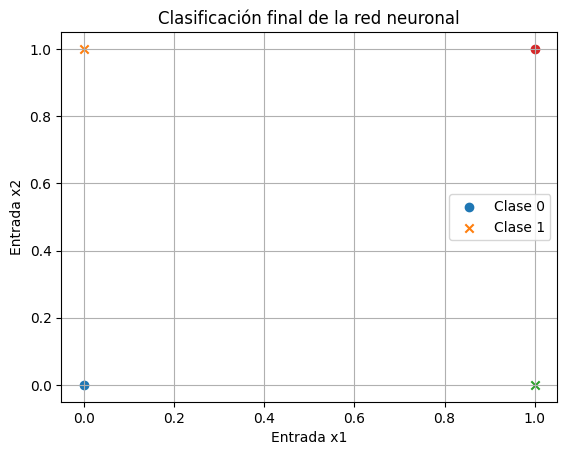

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])#contiene las entradas del modelo
y = np.array([0, 1, 1, 0]).reshape(-1, 1)#contiene las salidas esperadas. Se ajusta la forma a (4, 1)

#Con esto se observa la distribucion de clases
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], marker='o', label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], marker='x', label='Clase 1' if i == 1 else "")

plt.title("Datos del problema XOR")
plt.xlabel("Entrada x1")
plt.ylabel("Entrada x2")
plt.legend()
plt.grid(True)
plt.show()

#6.Definir la función de activación sigmoide (ESTE TRANSFORMA LOS VALORES ENTRE 0 Y 1,
#UTIL PARA PROBLEMAS DE CLASIFICACION BINARIA)
def sigmoide(x):
  return 1 / (1 + np.exp(-x))
#También se requiere la derivada de la función sigmoide, ya que será utilizada durante la
#retropropagación.
def derivada_sigmoide(x):
  return x * (1 - x)

#7.Inicializar los parámetros de la red neuronal
np.random.seed(42)
neuronas_entrada = 2
neuronas_ocultas = 4
neuronas_salida = 1
W1 = np.random.uniform(size=(neuronas_entrada, neuronas_ocultas))
b1 = np.random.uniform(size=(1, neuronas_ocultas)) #SESGO DE CAPA OCULTA
W2 = np.random.uniform(size=(neuronas_ocultas, neuronas_salida))
b2 = np.random.uniform(size=(1, neuronas_salida)) #SESGO DE CAPA DE SALIDA

#8.Comprender la propagación hacia adelante//////////////
##Z1 = XW1 + b1 SUMA PONDERADA DE LA CAPA OCULTA
#A1 = sigmoide(Z1) ACTIVACION DE LA CAPA OCULTA
#Después se calcula la salida final:
#Z2 = A1W2 + b2 SUMA PONDERADA DE LA CAPA DE SALIDA
#A2 = sigmoide(Z2) PREDICCION GRAL POR LA RED NEURONAL//////////

#9.Crear la función de propagación hacia adelante
def propagacion_adelante(X, W1, b1, W2, b2):
  Z1 = np.dot(X, W1) + b1
  A1 = sigmoide(Z1)
  Z2 = np.dot(A1, W2) + b2
  A2 = sigmoide(Z2)
  return Z1, A1, Z2, A2
  #////Esta función recibe los datos de entrada, pesos y sesgos.
  #Después calcula las salidas intermedias y la predicción final de la red neuronal. ///

#10.Definir la función de error
#ECM = promedio((y_real - y_predicha)²) El objetivo del entrenamiento será reducir este error.
def calcular_error(y_real, y_predicha):
  return np.mean((y_real - y_predicha) ** 2)

#11.Comprender la clasificación final
#///////La salida de la red neuronal será un número entre 0 y 1. Para convertir ese valor en una
#clase, se utilizará un umbral de decisión.
#La regla será:
#Si la predicción es mayor o igual a 0.5, la clase será 1.
#Si la predicción es menor que 0.5, la clase será 0. //////////////////////////////////

def clasificar(prediccion):
  if prediccion >= 0.5:
      return 1
  else:
      return 0
#12.Comprender la retropropagación
#La retropropagación permite calcular cómo deben modificarse los pesos y sesgos para
#reducir el error. 1-error_salida = y - A2   2-parametro_nuevo = parametro_actual + tasa_aprendizaje * ajuste

#13.Crear la función de entrenamiento
#Esta función realiza el entrenamiento completo de la red neuronal. En cada época, el
#modelo calcula predicciones, mide el error, aplica retropropagación y actualiza los pesos y sesgos.
def entrenar_red(X, y, W1, b1, W2, b2, tasa_aprendizaje, epocas):
    errores = []

    for epoca in range(epocas):
        Z1, A1, Z2, A2 = propagacion_adelante(X, W1, b1, W2, b2)

        error = y - A2
        error_promedio = calcular_error(y, A2)
        errores.append(error_promedio)

        ajuste_salida = error * derivada_sigmoide(A2)

        error_oculto = np.dot(ajuste_salida, W2.T)
        ajuste_oculto = error_oculto * derivada_sigmoide(A1)

        W2 = W2 + np.dot(A1.T, ajuste_salida) * tasa_aprendizaje
        b2 = b2 + np.sum(ajuste_salida, axis=0, keepdims=True) * tasa_aprendizaje
        W1 = W1 + np.dot(X.T, ajuste_oculto) * tasa_aprendizaje
        b1 = b1 + np.sum(ajuste_oculto, axis=0, keepdims=True) * tasa_aprendizaje

        if epoca % 1000 == 0:
            print("Época:", epoca, "Error:", error_promedio)

    return W1, b1, W2, b2, errores

#14.Entrenar la red neuronal
tasa_aprendizaje = 0.5
epocas = 10000
#Ejecuta el entrenamiento:
W1, b1, W2, b2, errores = entrenar_red(
    X,
    y,
    W1,
    b1,
    W2,
    b2,
    tasa_aprendizaje,
    epocas
)

Z1, A1, Z2, predicciones = propagacion_adelante(X, W1, b1, W2, b2)

#15.Obtener las predicciones finales
Z1, A1, Z2, predicciones = propagacion_adelante(X, W1, b1, W2, b2)
print("Predicciones finales:")
print(predicciones)

#16.Convertir las predicciones en clases
clases_predichas = []
for prediccion in predicciones:
  clase = clasificar(prediccion[0])
  clases_predichas.append(clase)
clases_predichas = np.array(clases_predichas).reshape(-1, 1)
print("Clases predichas:")
print(clases_predichas)

#17.Comparar resultados
print("Comparación de resultados:")
for i in range(len(X)):
  print("Entrada:", X[i])
  print("Salida esperada:", y[i][0])
  print("Predicción:", predicciones[i][0])
  print("Clase predicha:", clases_predichas[i][0])
  print("-----------------------------")

  #18.Calcular la exactitud del modelo

aciertos = np.sum(clases_predichas == y)
exactitud = aciertos / len(y)

print("Exactitud del modelo:", exactitud)

#19.Graficar el error durante el entrenamiento
plt.plot(errores)
plt.title("Error durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")
plt.grid(True)
plt.show()

#20.Graficar la clasificación final
for i in range(len(X)):
  if clases_predichas[i] == 0:
    plt.scatter(X[i, 0], X[i, 1], marker='o', label='Clase 0' if i == 0 else "")
  else:
    plt.scatter(X[i, 0], X[i, 1], marker='x', label='Clase 1' if i == 1 else "")
plt.title("Clasificación final de la red neuronal")
plt.xlabel("Entrada x1")
plt.ylabel("Entrada x2")
plt.legend()
plt.grid(True)
plt.show()